INTERN ID : IN126014402

Task 4: Fine-Tuning BERT on a Kaggle Dataset

Dataset Used : IMDB Movie Reviews

Step 1 : Install Required Libraries

In [ ]:
# Install Hugging Face Transformers and Datasets
!pip install --upgrade transformers datasets accelerate -q

# Imports
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 92.4 MB/s eta 0:00:00
,

Load Dataset

In [ ]:

df = pd.read_csv("/contents/IMDB Dataset.csv")

# Preview
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Data Preprocessing

In [ ]:
# Drop missing values
df = df.dropna()

# Optional: lowercase & remove unwanted characters
df['review'] = df['review'].str.lower().str.replace(r"[^a-zA-Z0-9\s]", "", regex=True)

# Encode labels (if needed)
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

Split Data

In [ ]:
# Train / Validation / Test Split
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'], df['sentiment'], test_size=0.3, random_state=42, stratify=df['sentiment']
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

# Convert to Dataset objects
from datasets import Dataset
train_dataset = Dataset.from_dict({'text': train_texts.tolist(), 'label': train_labels.tolist()})
val_dataset = Dataset.from_dict({'text': val_texts.tolist(), 'label': val_labels.tolist()})
test_dataset = Dataset.from_dict({'text': test_texts.tolist(), 'label': test_labels.tolist()})

Tokenization

In [ ]:
# Load BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize function
def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True, max_length=128)

# Apply tokenization
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Set format for PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
,The secret `HF_TOKEN` does not exist in your Colab secrets.
,To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
,You will be able to reuse this secret in all of your notebooks.
,Please note that authentication is recommended but still optional to access public models or datasets.
,  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

,WARNING:huggingface_hub.utils._http:Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/35000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7500 [00:00<?, ? examples/s]

Map:   0%|          | 0/7500 [00:00<?, ? examples/s]

Model Building

In [ ]:
# Load pre-trained BERT for sequence classification
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("Training on device:", device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
,Key                                        | Status     | 
,-------------------------------------------+------------+-
,cls.seq_relationship.weight                | UNEXPECTED | 
,cls.predictions.transform.dense.weight     | UNEXPECTED | 
,cls.predictions.transform.dense.bias       | UNEXPECTED | 
,cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
,cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
,cls.seq_relationship.bias                  | UNEXPECTED | 
,cls.predictions.bias                       | UNEXPECTED | 
,classifier.weight                          | MISSING    | 
,classifier.bias                            | MISSING    | 
,
,Notes:
,- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
,- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training on device: cpu


Define Metrics

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

Trainer Setup & Fine-Tuning

In [ ]:
# Optimized Training Arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,                # faster for Colab
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=1,
    dataloader_pin_memory=False,
    report_to="none",
    load_best_model_at_end=True,
    optim="adamw_torch" # Explicitly use non-fused AdamW optimizer
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# Start fine-tuning
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.274248,0.261802,0.901067,0.903217,0.898400,0.900802


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.274248,0.261802,0.901067,0.903217,0.898400,0.900802
2,0.195534,0.326703,0.899200,0.900053,0.898133,0.899092


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=4376, training_loss=0.2482988609910229, metrics={'train_runtime': 1028.9105, 'train_samples_per_second': 68.049, 'train_steps_per_second': 4.253, 'total_flos': 4604443468800000.0, 'train_loss': 0.2482988609910229, 'epoch': 2.0})

Evaluation on Test Set

In [ ]:
# Predict
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(-1)

# Metrics
acc = accuracy_score(test_dataset['label'], preds)
prec = precision_score(test_dataset['label'], preds)
rec = recall_score(test_dataset['label'], preds)
f1 = f1_score(test_dataset['label'], preds)
cm = confusion_matrix(test_dataset['label'], preds)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(cm)

Accuracy: 0.8983
,Precision: 0.8954
,Recall: 0.9019
,F1 Score: 0.8986
,Confusion Matrix:
,[[3355  395]
, [ 368 3382]]


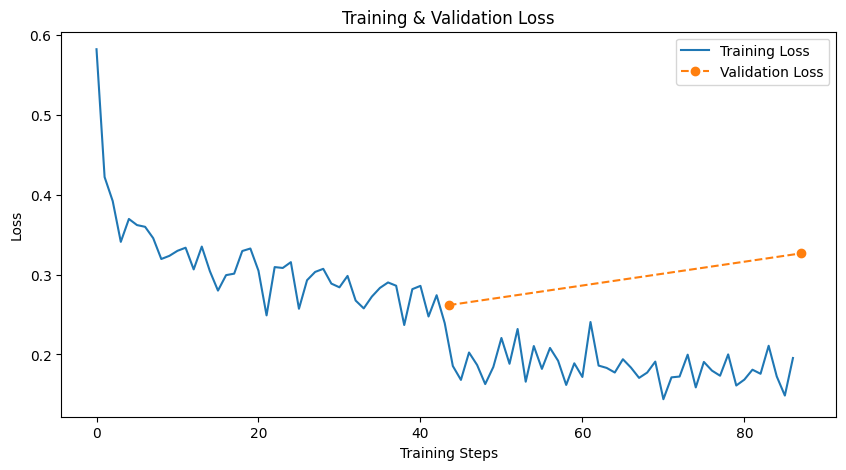

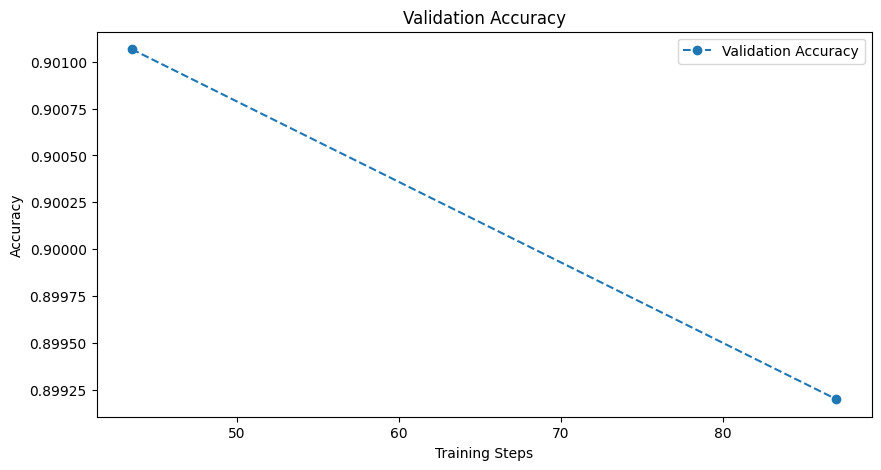

In [ ]:
import matplotlib.pyplot as plt

# Extract log history
logs = trainer.state.log_history

# Get lists for metrics
train_loss = [x['loss'] for x in logs if 'loss' in x]
eval_loss = [x['eval_loss'] for x in logs if 'eval_loss' in x]
eval_accuracy = [x['eval_accuracy'] for x in logs if 'eval_accuracy' in x]

# Calculate x-coordinates for validation metrics
# These should correspond to the end of each epoch relative to the training loss steps
if len(eval_loss) > 0 and len(train_loss) > 0:
    # Calculate approximate steps per evaluation point
    # Assuming eval_loss is recorded once per epoch, and train_loss is recorded over total steps
    steps_per_eval_point = len(train_loss) / len(eval_loss)
    eval_x_coords = [(i + 1) * steps_per_eval_point for i in range(len(eval_loss))]
else:
    # Handle cases where no evaluation data exists to prevent errors
    eval_x_coords = []

# Plot training & validation loss
plt.figure(figsize=(10,5))
plt.plot(range(len(train_loss)), train_loss, label='Training Loss') # Plot train_loss against its own indices
if eval_x_coords: # Only plot if eval data exists
    plt.plot(eval_x_coords, eval_loss, label='Validation Loss', marker='o', linestyle='--')
plt.title('Training & Validation Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot validation accuracy
plt.figure(figsize=(10,5))
if eval_x_coords: # Only plot if eval data exists
    plt.plot(eval_x_coords, eval_accuracy, label='Validation Accuracy', marker='o', linestyle='--')
plt.title('Validation Accuracy')
plt.xlabel('Training Steps')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

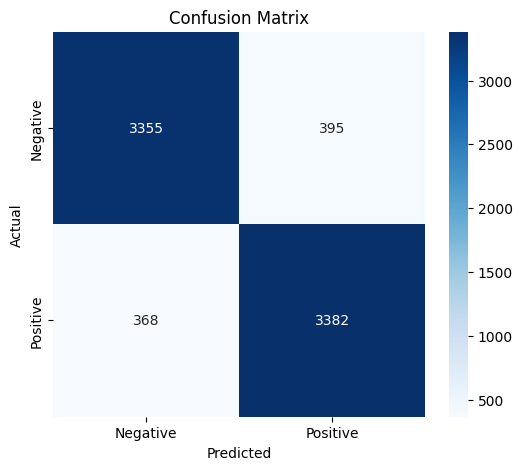

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(test_dataset['label'], preds)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Freeze BERT layers

In [ ]:
for param in model.bert.parameters():
    param.requires_grad = False

Fine-tune last 2 layers only

In [ ]:
for name, param in model.bert.named_parameters():
    if "encoder.layer.10" not in name and "encoder.layer.11" not in name:
        param.requires_grad = False